# Feature (Variable) Importance – Stage 2 Metadata Models

This notebook loads trained XGBoost and Random Forest models, extracts feature importance, and plots horizontal bar charts.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from joblib import load
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb

from Stage2.data.preprocess import TabularPreprocessor

## XGBoost – Feature importance (gain)

In [2]:
preprocessor_path = PROJECT_ROOT / "Stage2/checkpoints/xgboost/preprocessor.joblib"
ckpt_path = PROJECT_ROOT / "Stage2/checkpoints/xgboost/best.json"

preprocessor = TabularPreprocessor.load(preprocessor_path)
feature_names = preprocessor.artifacts.feature_names

booster = xgb.Booster()
booster.load_model(str(ckpt_path))
score = booster.get_score(importance_type="gain")
importance = np.array([score.get(f"f{i}", 0) for i in range(len(feature_names))])

df_xgb = pd.DataFrame({"feature": feature_names, "importance": importance})
df_xgb = df_xgb.sort_values("importance", ascending=True)
df_xgb.tail(10)

,feature,importance
403,fitzpatrick,6.844881
358,bleed_true,7.174053
405,diameter_2,7.178569
402,age,7.572905
404,lesion_size_mm,7.762363
377,elevation_false,8.411046
378,elevation_true,8.536335
386,alcohol_consumption_unknown,16.137901
383,smoking_unknown,39.536396
366,itch_true,90.122292


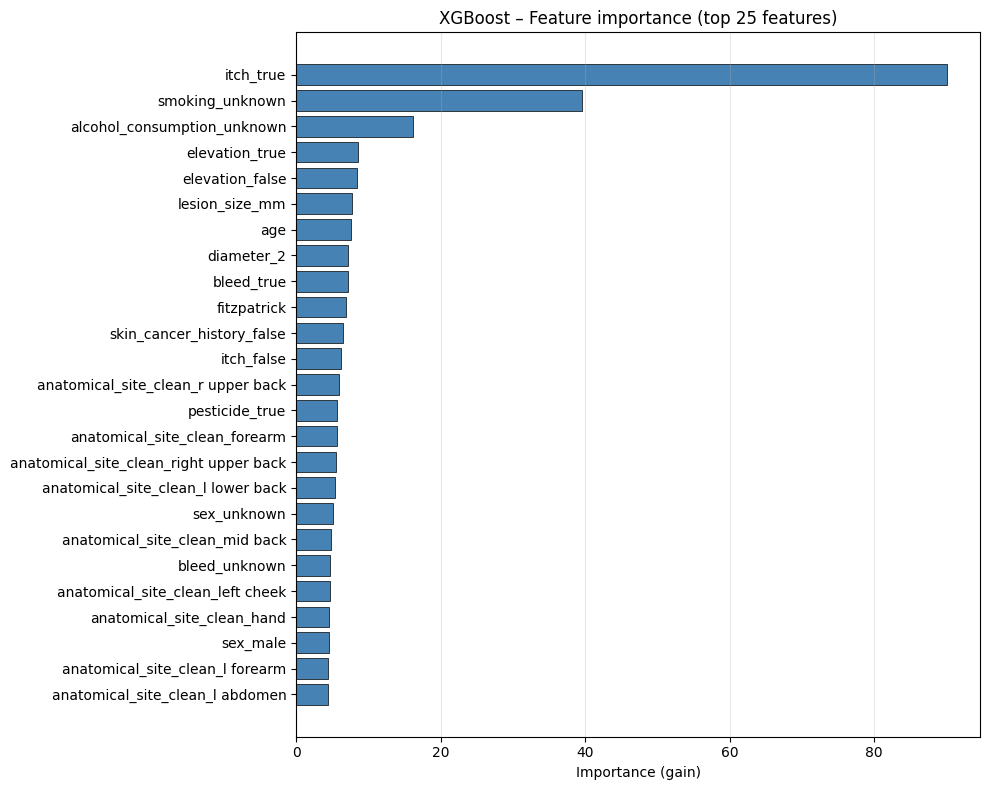

In [3]:
top_n = 25
df_plot = df_xgb.tail(top_n)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df_plot["feature"], df_plot["importance"], color="steelblue", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Importance (gain)")
ax.set_title("XGBoost – Feature importance (top {} features)".format(top_n))
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Random Forest – Feature importance

In [4]:
preprocessor_path_rf = PROJECT_ROOT / "Stage2/checkpoints/random_forest/preprocessor.joblib"
ckpt_path_rf = PROJECT_ROOT / "Stage2/checkpoints/random_forest/best.joblib"

preprocessor_rf = TabularPreprocessor.load(preprocessor_path_rf)
feature_names_rf = preprocessor_rf.artifacts.feature_names

model_rf = load(ckpt_path_rf)
importance_rf = model_rf.feature_importances_

df_rf = pd.DataFrame({"feature": feature_names_rf, "importance": importance_rf})
df_rf = df_rf.sort_values("importance", ascending=True)
df_rf.tail(10)

,feature,importance
383,smoking_unknown,0.011401
401,has_sewage_system_unknown,0.013387
378,elevation_true,0.013870
365,itch_false,0.016933
377,elevation_false,0.017148
405,diameter_2,0.017275
403,fitzpatrick,0.035179
366,itch_true,0.035868
404,lesion_size_mm,0.097042
402,age,0.165509


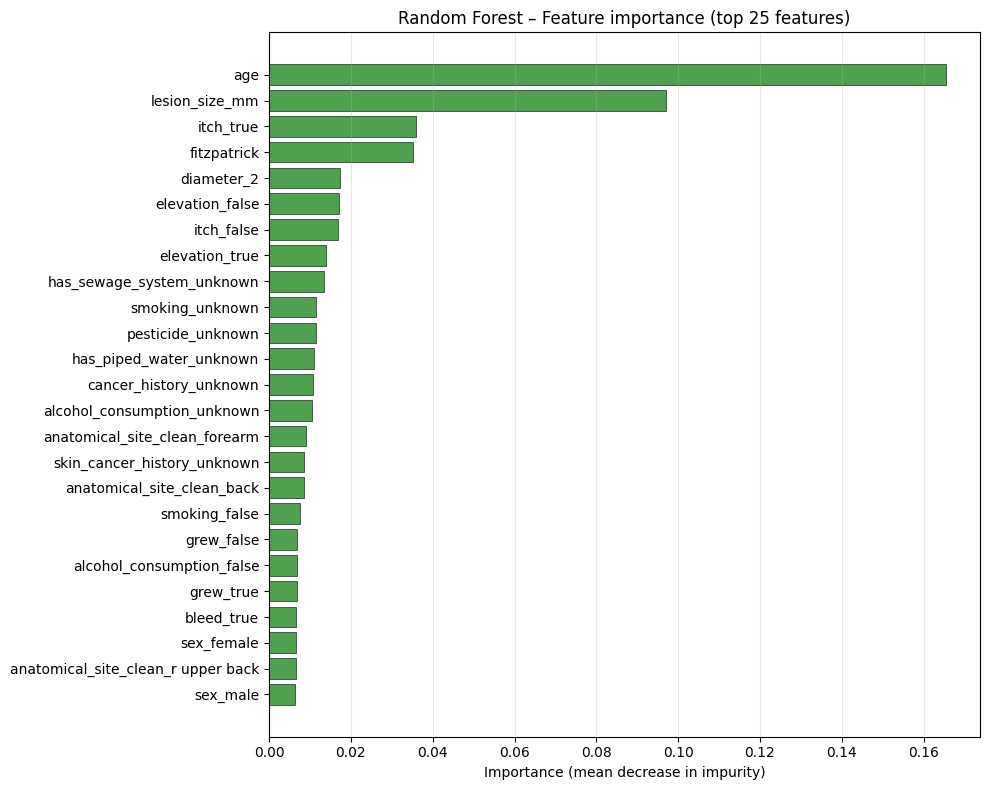

In [5]:
top_n = 25
df_plot_rf = df_rf.tail(top_n)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df_plot_rf["feature"], df_plot_rf["importance"], color="forestgreen", alpha=0.8, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_title("Random Forest – Feature importance (top {} features)".format(top_n))
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Save plots (optional)

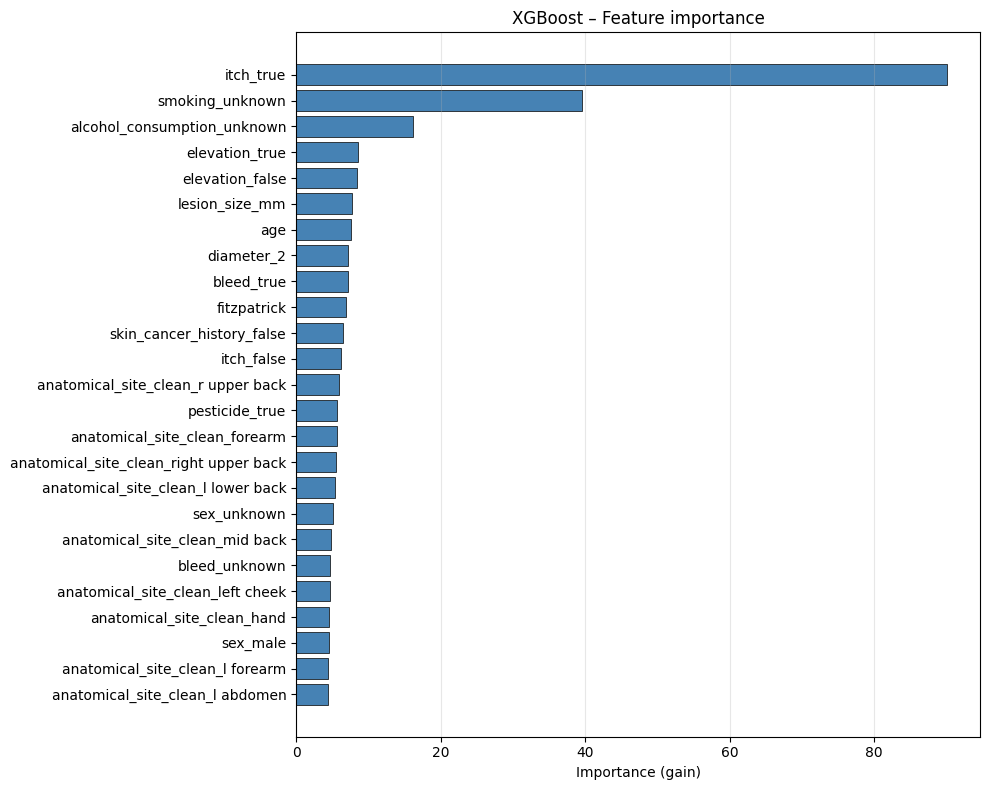

Saved: /Users/dimitriskaltsios/University/Individual/Kaltsios-Individual-Project/Stage2/checkpoints/xgboost/feature_importance.png


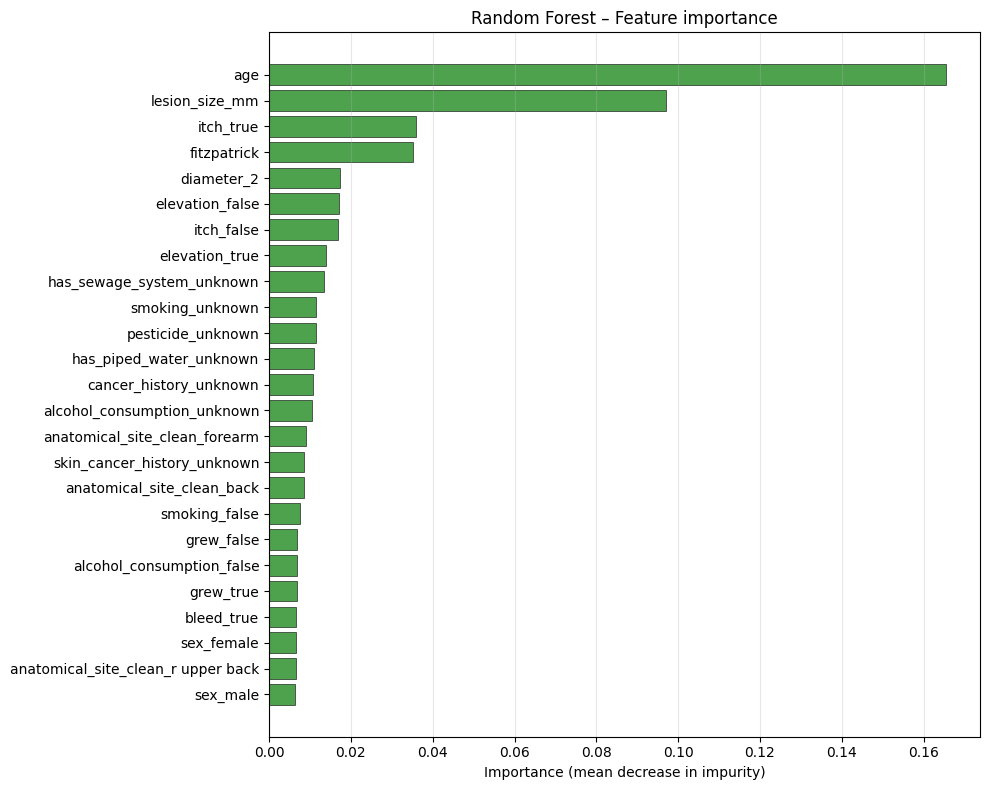

Saved: /Users/dimitriskaltsios/University/Individual/Kaltsios-Individual-Project/Stage2/checkpoints/random_forest/feature_importance.png


In [6]:
out_dir = PROJECT_ROOT / "Stage2/checkpoints"

# XGBoost
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df_xgb.tail(25)["feature"], df_xgb.tail(25)["importance"], color="steelblue", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Importance (gain)")
ax.set_title("XGBoost – Feature importance")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(out_dir / "xgboost/feature_importance.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", out_dir / "xgboost/feature_importance.png")

# Random Forest
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df_rf.tail(25)["feature"], df_rf.tail(25)["importance"], color="forestgreen", alpha=0.8, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_title("Random Forest – Feature importance")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(out_dir / "random_forest/feature_importance.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", out_dir / "random_forest/feature_importance.png")